In [1]:
import glob
import matplotlib.pyplot as plt
import sys
import xarray as xr
import numpy as np
import pandas as pd
import re
from matplotlib.lines import Line2D
import os
from matplotlib import cm
import matplotlib.patches as mpatches
from matplotlib import ticker
from matplotlib.path import Path
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
import matplotlib.gridspec as gridspec
import csv

sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

temp_groups = ['205', '218', '225']
color_map = {
    '205': 'gray',
    '218': 'red',
    '225': 'green'
}

rho_ice = 917.0  # kg/m^3, used for CoCiP mass calculation
model_colors = {"APCEMM": "tab:blue", "LES": "tab:orange", "CoCiP": "tab:green"}
rh_styles = {110: "--", 130: "-"}

In [2]:
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']
hours = [0, 12]
habits = ['ghm', 'solid-column', 'rough-aggregate']
base_dir = '/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results'

# APCEMM
apcemm_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/APCEMM/{tid}/APCEMM_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

apcemm_default_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/APCEMM/default_settings/{tid}/APCEMM_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# CoCiP
cocip_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/CoCiP/slicing_update/{tid}/CoCiP_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# LES
les_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/LES/slicing_update/{tid}/LES_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

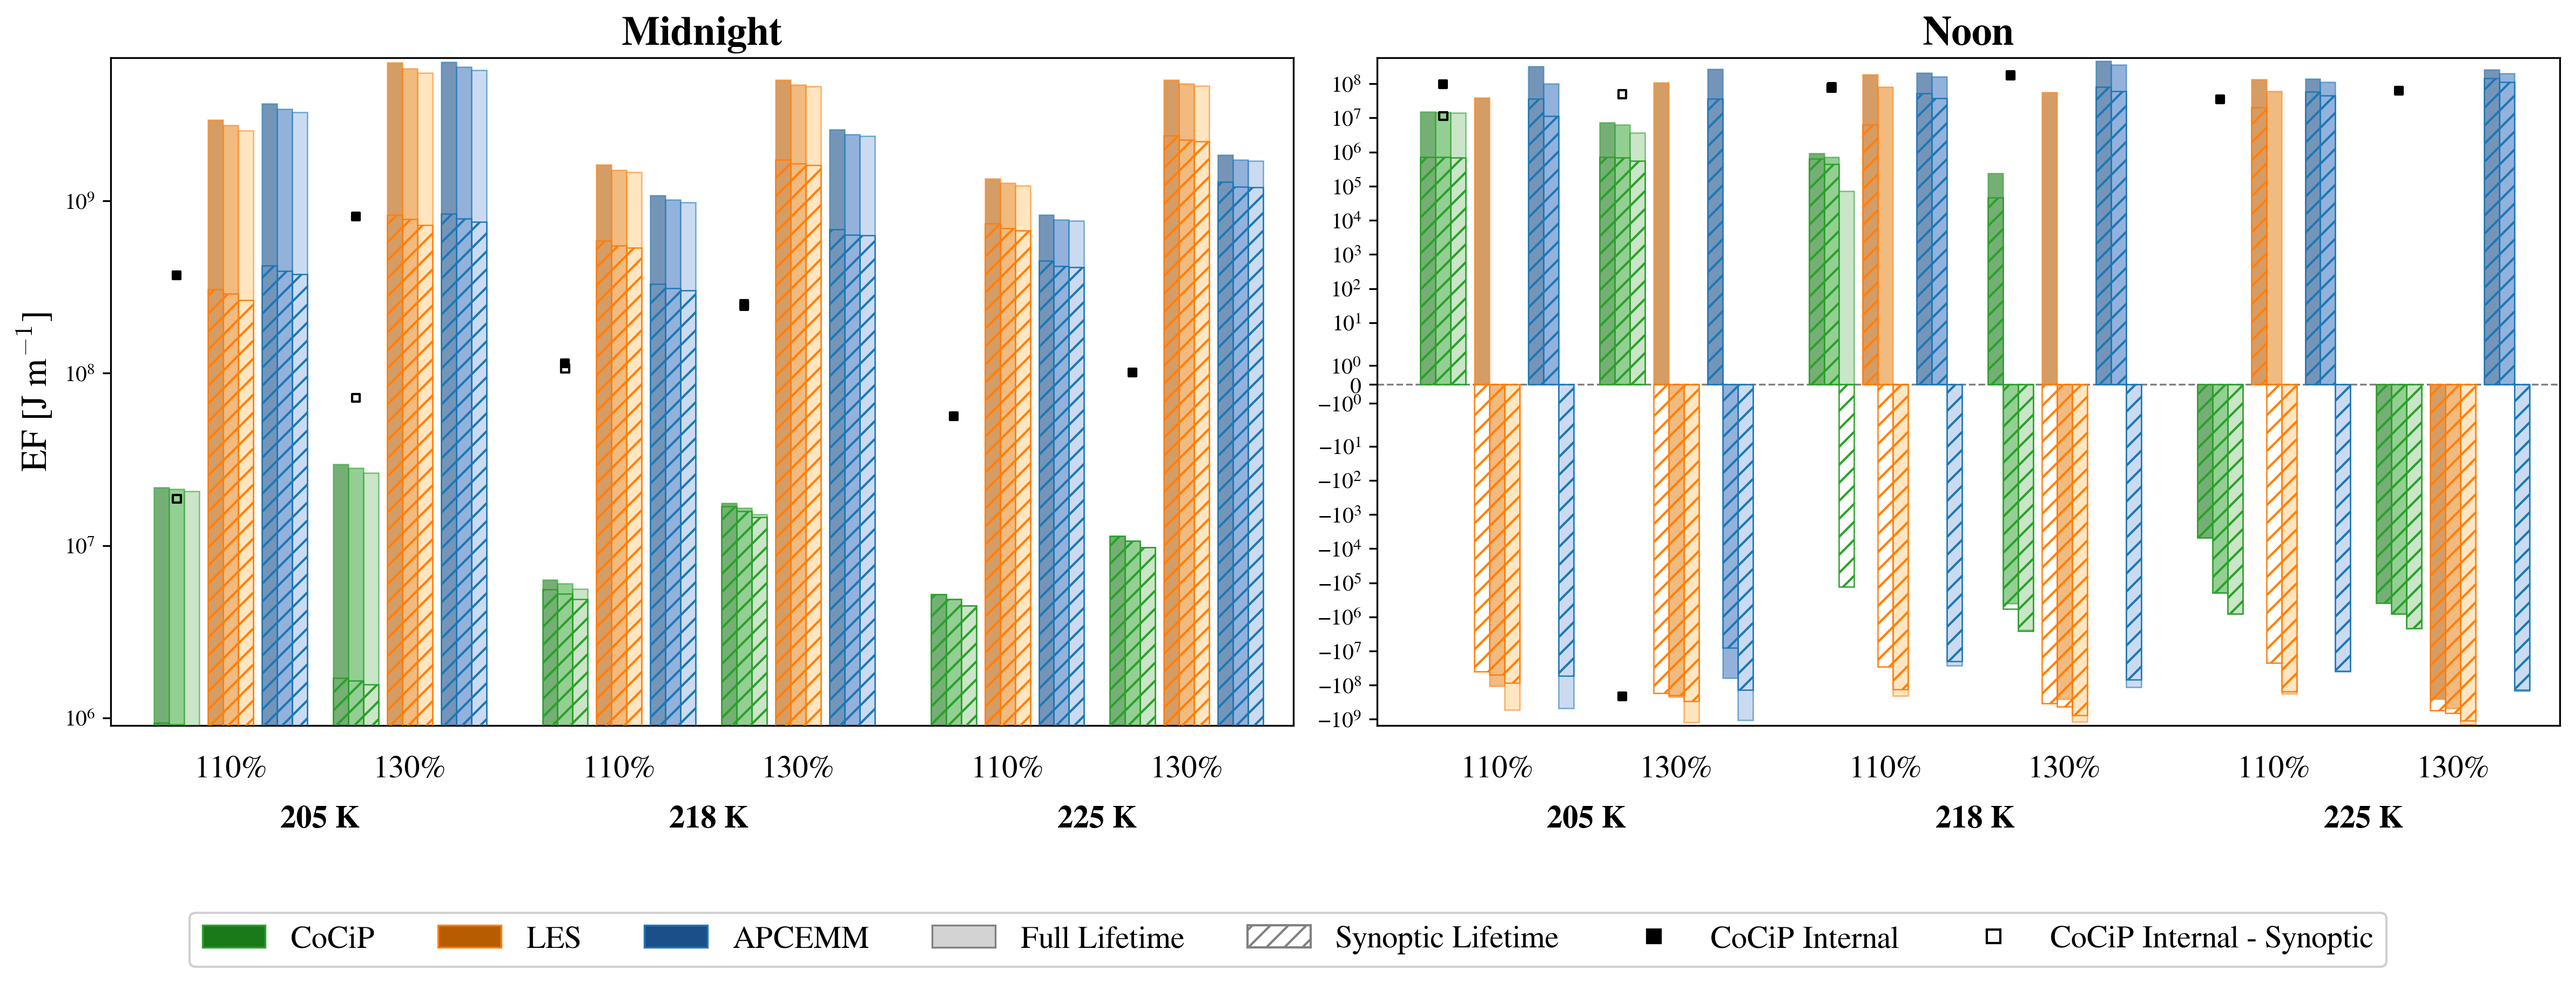

In [4]:
# ── data paths & keys ────────────────────────────────────────────────────────
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']
hours    = [0, 12]
habits   = ['solid-column', 'ghm', 'rough-aggregate']
base_dir = '/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results'

TARGET_AGE_H = 4.0

# ── helper: age coordinate per model ─────────────────────────────────────────
def get_age_coord(ds, m):
    if m == 'APCEMM':
        return ds['t'].values.astype(float)
    elif m == 'LES':
        return ds['time'].values.astype(float)
    elif m == 'CoCiP':
        return ds['age_hours'].values.astype(float)
    else:
        raise ValueError(f"Unknown model: {m}")

def get_ds(m, tid, hour, habit):
    key = (tid, hour, habit)
    if m == 'APCEMM':
        return apcemm_data.get(key)
    elif m == 'CoCiP':
        return cocip_data.get(key)
    elif m == 'LES':
        return les_data.get(key)

# ── accumulate per-habit EF values ───────────────────────────────────────────
# Keyed by (tid, model, hour, habit) — one scalar each
per_case    = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in ['APCEMM', 'CoCiP', 'LES']} for tid in test_ids}
per_case_4h = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in ['APCEMM', 'CoCiP', 'LES']} for tid in test_ids}

for m in ['APCEMM', 'CoCiP', 'LES']:
    for tid in test_ids:
        for hour in hours:
            for habit in habits:
                ds = get_ds(m, tid, hour, habit)
                if ds is None:
                    continue

                age     = get_age_coord(ds, m)
                ef_vals = ds['Energy Forcing'].values.astype(float)

                # full run: last EF value (remove index-0 for APCEMM)
                ef_full = (ef_vals[1:] - ef_vals[0]) if (m == 'APCEMM' and len(ef_vals) > 1) else ef_vals
                if len(ef_full) > 0:
                    per_case[tid][m][hour][habit] = float(ef_full[-1])

                # 4h truncated: last EF value at or before 4 h
                ef_4h = ef_vals[age <= TARGET_AGE_H]
                if len(ef_4h) > 0:
                    per_case_4h[tid][m][hour][habit] = float(ef_4h[-1])

# ── CoCiP internal EF (unchanged logic) ──────────────────────────────────────
def get_cocip_internal_point(tid, hour, target_h):
    cbd = get_ds('CoCiP', tid, hour, 'ghm')
    if cbd is None:
        return np.nan

    age_hours   = cbd['age_hours'].values.astype(float)
    ef_vals     = cbd['ef'].values.astype(float)
    seg_lengths = cbd['segment_length'].values.astype(float)

    max_contrail_age = age_hours[-1]

    if target_h is None:
        idx = len(age_hours) - 2
    elif target_h >= max_contrail_age:
        return np.nan
    else:
        idx = np.argmin(np.abs(age_hours - target_h))
        idx = max(0, idx - 1)

    ef_cocip_internal = np.cumsum(ef_vals[1:] / seg_lengths[1:])

    if idx >= len(ef_cocip_internal):
        return np.nan

    return ef_cocip_internal[idx]

cocip_internal = {}
for tid in test_ids:
    for hour in hours:
        cocip_internal[(tid, hour, 'none')] = get_cocip_internal_point(tid, hour, None)
        cocip_internal[(tid, hour, '4h')]   = get_cocip_internal_point(tid, hour, TARGET_AGE_H)

# ── color definitions ─────────────────────────────────────────────────────────
# Three shades per model: dark → mid → light for ghm → solid-column → rough-aggregate
model_habit_colors = {
    'CoCiP':  {'solid-column': '#1a7a1a', 'ghm': '#4caf4c', 'rough-aggregate': '#a8d5a2'},
    'LES':    {'solid-column': '#b85c00', 'ghm': '#e88c2a', 'rough-aggregate': '#ffd699'},
    'APCEMM': {'solid-column': '#1a4f8a', 'ghm': '#4a80c4', 'rough-aggregate': '#a8c4e8'},
}
model_edge_colors = {'CoCiP': 'tab:green', 'LES': 'tab:orange', 'APCEMM': 'tab:blue'}

# ── layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300, sharey=False)

temps_unique = sorted({int(tid.split('T')[1].split('L')[0]) for tid in test_ids})

groups = []
for T in temps_unique:
    for tid in sorted([t for t in test_ids if f"T{T}" in t],
                      key=lambda s: int(s[:3])):
        groups.append((T, tid))

model_order  = ['CoCiP', 'LES', 'APCEMM']
n_models     = len(model_order)
n_habits     = len(habits)
sub_bar_w    = 0.07   # width of each individual habit bar
model_gap    = 0.04   # gap between model clusters
group_gap    = 0.14   # extra gap between temperature groups

model_cluster_w = n_habits * sub_bar_w  # total width of one model's 3 bars

def group_x_positions(groups):
    x0, positions, prev_T = 0.0, [], None
    for (T, tid) in groups:
        if prev_T is not None and T != prev_T:
            x0 += group_gap
        positions.append(x0)
        x0 += n_models * (model_cluster_w + model_gap) + 0.08
        prev_T = T
    return positions

group_starts = group_x_positions(groups)

x_left  = -0.2
x_right = group_starts[-1] + n_models * (model_cluster_w + model_gap) + 0.1

# ── draw bars ─────────────────────────────────────────────────────────────────
def draw_bars(ax, hour):
    for gi, (T, tid) in enumerate(groups):
        x_group = group_starts[gi]
        for mi, m in enumerate(model_order):
            x_model = x_group + mi * (model_cluster_w + model_gap)
            edge_col = model_edge_colors[m]

            for hi, habit in enumerate(habits):
                xc        = x_model + hi * sub_bar_w
                xc_center = xc + sub_bar_w / 2
                fill_col  = model_habit_colors[m][habit]

                # ---- full run bar ----
                yf = per_case[tid][m][hour][habit]
                if yf is not None:
                    ax.bar(xc, abs(yf), bottom=min(yf, 0), width=sub_bar_w,
                           align='edge', color=fill_col, edgecolor=edge_col,
                           linewidth=0.6, zorder=2, alpha=0.6)

                # ---- 4h truncated overlay (hatch, no fill) ----
                y4 = per_case_4h[tid][m][hour][habit]
                if y4 is not None:
                    ax.bar(xc, abs(y4), bottom=min(y4, 0), width=sub_bar_w,
                           align='edge', color='None', edgecolor=edge_col,
                           linewidth=0.6, hatch='///', zorder=3)

# ── CoCiP internal scatter ────────────────────────────────────────────────────
# Place the scatter at the horizontal center of the CoCiP model cluster
cocip_idx = model_order.index('CoCiP')

def draw_cocip_internal(ax, hour):
    for gi, (_, tid) in enumerate(groups):
        x_model = group_starts[gi] + cocip_idx * (model_cluster_w + model_gap)
        x = x_model + model_cluster_w / 2   # centre of the CoCiP cluster

        y_none = cocip_internal.get((tid, hour, 'none'), np.nan)
        if np.isfinite(y_none):
            ax.scatter(x, y_none, marker='s', s=12,
                       facecolors='black', edgecolors='black', zorder=6)

        y_4h = cocip_internal.get((tid, hour, '4h'), np.nan)
        if np.isfinite(y_4h):
            ax.scatter(x, y_4h, marker='s', s=12,
                       facecolors='none', edgecolors='black', zorder=6)

# ── main panels ───────────────────────────────────────────────────────────────
panel_info = list(zip(axes, hours, ['Midnight', 'Noon']))

for ax, hour, title in panel_info:
    draw_bars(ax, hour)
    draw_cocip_internal(ax, hour)

    ax.axhline(0, color='gray', linestyle='--', lw=0.8)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xticks([])
    ax.set_xlim(x_left, x_right)

# ── y limits ──────────────────────────────────────────────────────────────────
for ax, hour, title in panel_info:
    ymins, ymaxs = [], []
    for tid in test_ids:
        for m in model_order:
            for habit in habits:
                for val_dict in [per_case, per_case_4h]:
                    v = val_dict[tid][m][hour][habit]
                    if v is not None:
                        ymins.append(v)
                        ymaxs.append(v)
        for mode in ['none', '4h']:
            y_int = cocip_internal.get((tid, hour, mode), np.nan)
            if np.isfinite(y_int):
                ymins.append(y_int)
                ymaxs.append(y_int)

    ymin = min(ymins) if ymins else -1
    ymax = max(ymaxs) if ymaxs else  1
    pad  = 0.06 * (ymax - ymin)

    if hour == 0:
        ax.set_ylim(ymin, ymax + pad)
    else:
        ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_yscale('symlog')

axes[0].set_ylabel('EF [J m$^{-1}$]', fontsize=16)

# ── x-tick labels ─────────────────────────────────────────────────────────────
for ax, hour, title in panel_info:

    # RHI labels — centred on the full group of 3 model clusters
    for gi, (T, tid) in enumerate(groups):
        total_w = n_models * (model_cluster_w + model_gap) - model_gap
        xc = group_starts[gi] + total_w / 2
        rhi_str = tid[:3] + '%'
        ax.text(xc, -0.045, rhi_str, ha='center', va='top', fontsize=14,
                transform=ax.get_xaxis_transform(), clip_on=False)

    # Temperature labels
    prev_T, block_start_x = None, None

    def flush_temp_label(ax, T, bsx, bex):
        ax.text((bsx + bex) / 2, -0.12, f'{T} K',
                ha='center', va='top', fontsize=14, fontweight='bold',
                transform=ax.get_xaxis_transform(), clip_on=False)

    for gi, (T, tid) in enumerate(groups):
        if T != prev_T:
            if prev_T is not None:
                flush_temp_label(ax, prev_T, block_start_x,
                                 group_starts[gi - 1] + n_models * (model_cluster_w + model_gap) - model_gap)
            block_start_x = group_starts[gi]
            prev_T = T

    flush_temp_label(ax, prev_T, block_start_x,
                     group_starts[-1] + n_models * (model_cluster_w + model_gap) - model_gap)

# ── legend ────────────────────────────────────────────────────────────────────
# Model patches (mid shade)
model_handles = [
    mpatches.Patch(facecolor=model_habit_colors[m]['solid-column'],
                   edgecolor=model_edge_colors[m], linewidth=0.8, label=m)
    for m in model_order
]

# Habit shade patches (using APCEMM palette as neutral reference)
habit_labels = {'ghm': 'GHM', 'solid-column': 'Solid Column', 'rough-aggregate': 'Rough Aggregate'}
habit_handles = [
    mpatches.Patch(facecolor=model_habit_colors['APCEMM'][hab],
                   edgecolor=model_edge_colors['APCEMM'], linewidth=0.8,
                   label=habit_labels[hab])
    for hab in habits
]

full_patch = mpatches.Patch(facecolor='lightgray', edgecolor='gray',
                             linewidth=0.8, label='Full Lifetime')
trunc_patch = mpatches.Patch(facecolor='None', edgecolor='gray',
                              hatch='///', label='Synoptic Lifetime')

internal_none_handle = plt.Line2D([0], [0], marker='s', linestyle='None',
                                   color='black', markerfacecolor='black',
                                   markeredgecolor='black', markersize=6,
                                   label='CoCiP Internal')
internal_4h_handle = plt.Line2D([0], [0], marker='s', linestyle='None',
                                 color='black', markerfacecolor='none',
                                 markeredgecolor='black', markersize=6,
                                 label='CoCiP Internal - Synoptic')

fig.legend(
    handles=model_handles + [full_patch, trunc_patch,
                                              internal_none_handle, internal_4h_handle],
    loc='lower center',
    ncol=7,
    fontsize=14,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.02)
)

# ── final layout ──────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

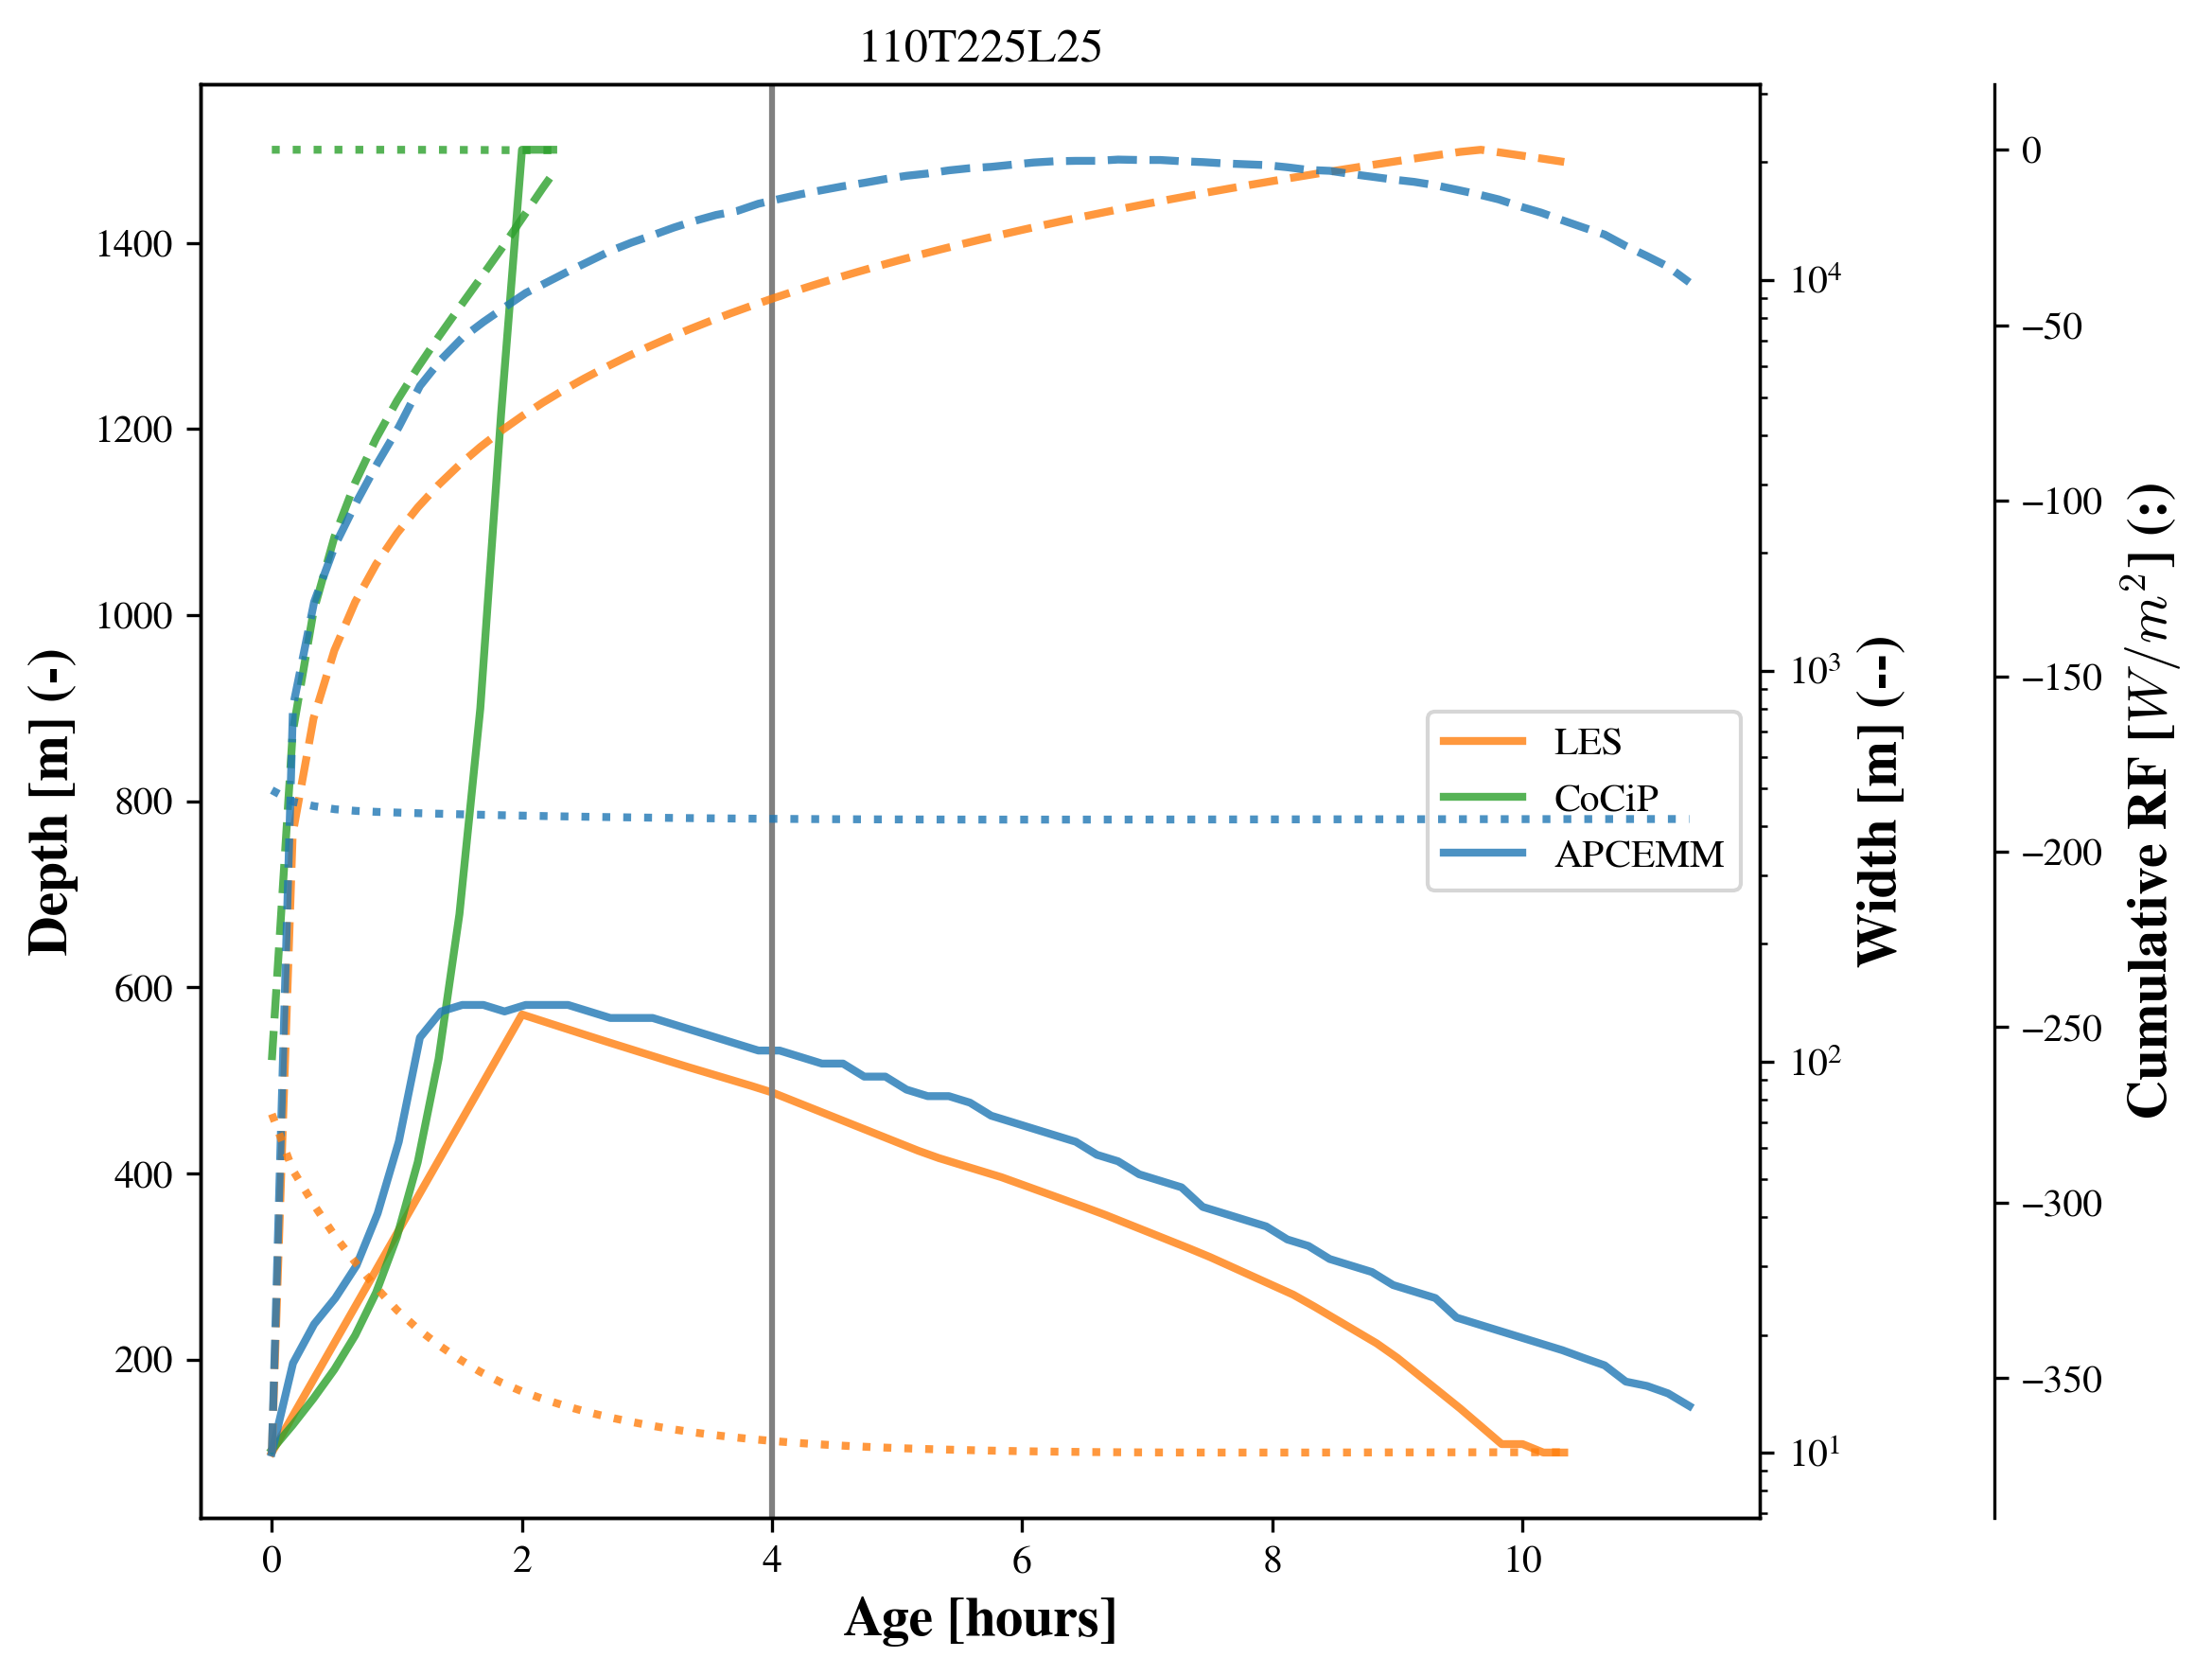

In [12]:
cases = ['110T225L25']
fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.15))

habit = 'rough-aggregate' # Plotted data is habit independent
tod = '12' # Plotted data is time of day independent
models = ['LES', 'CoCiP', 'APCEMM']
case_ls = {'110T205L25': '-', '130T205L25': '--'}

LES_var_names = ['Depth_m', 'Width_m', 'cs RF']
cocip_var_names = ['depth', 'width', 'cs RF']
APCEMM_var_names = ['depth', 'width', 'cs RF']

var_ls = {'Depth_m': '-', 
          'Width_m': '--',
          'depth': '-',
          'width': '--', 
          'cs RF': ':'
        }

axes_map = {0: ax1, 1: ax2, 2: ax3}

for model in models:
    for case in cases:
        if model == 'APCEMM':
            ds = apcemm_data.get((case, int(tod), habit))
            time_name = 't'
            vars = APCEMM_var_names
        elif model == 'LES':
            ds = les_data.get((case, int(tod), habit))
            time_name = 'time'
            vars = LES_var_names
        elif model == 'CoCiP':
            ds = cocip_data.get((case, int(tod), habit))
            time_name = 'age_hours'
            vars = cocip_var_names
            
        for i, var in enumerate(vars):
            ax = axes_map[i]
        
            times = ds[time_name].values

            if var == 'cs RF':
                if tod == '0':
                    var_vals = np.cumsum(ds['LW RF midnight'].values.astype(float))
                else:
                    if model == 'APCEMM' and (case == '110T205L25' or case == '130T205L25'):
                        var_vals = np.cumsum(ds['LW RF midnight'].values.astype(float) + ds['SW RF noon'].values.astype(float))
                    else:
                        var_vals = np.cumsum(ds['LW RF noon'].values.astype(float) + ds['SW RF noon'].values.astype(float))
            else:
                var_vals = ds[var].values.astype(float)
            if model == 'APCEMM' and var == 'Effective radius slices':
                var_vals = var_vals.mean(axis=1)
            if model == 'CoCiP' and var == 'r_ice_vol':
                var_vals = var_vals * 1e6
            if model == 'APCEMM' and var == 'IWC slices':
                var_vals = var_vals.mean(axis=1)
            if model == 'CoCiP' and var == 'iwc':
                var_vals = ds[var].values * ds["rho_air"].values * 1e3

            ax.plot(times, var_vals, label=model, lw=2, color=model_colors[model], alpha=0.8, linestyle=var_ls[var])
    

ax1.set_ylabel('Depth [m] (-)', fontsize=14, fontweight="bold")
ax2.set_ylabel('Width [m] (--)', fontsize=14, fontweight="bold")
ax3.set_ylabel('Cumulative RF [$W/m^{2}$] (:)', fontsize=14, fontweight="bold")
ax1.set_xlabel("Age [hours]", fontsize=14, fontweight="bold")
ax2.set_yscale("log")

handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='center right')

ax1.set_title(cases[0])

ax1.axvline(x=4, color='gray')

plt.tight_layout()
plt.show()

110T205L25
('APCEMM', '110T205L25', 12, 'solid-column')


NameError: name 'calculate_energy_forcing' is not defined

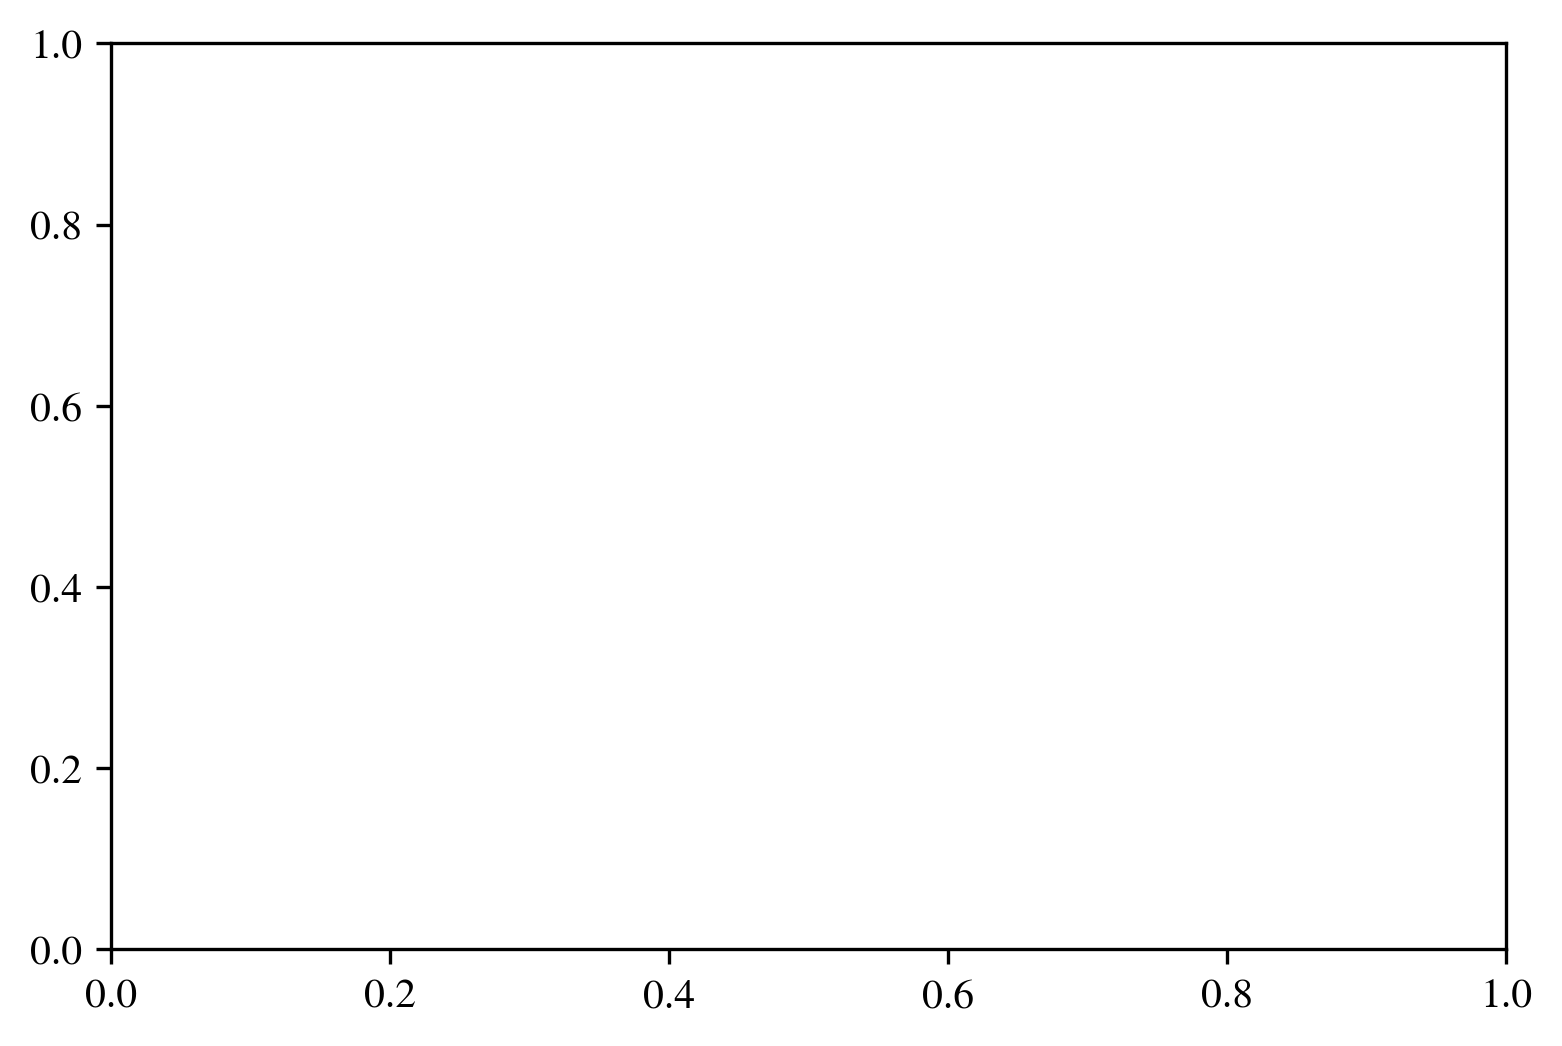

In [7]:
fig, ax = plt.subplots(dpi = 300)

# ── data paths & keys ─────────────────────────────────────────────────────────
test_ids = ['110T205L25', '110T218L25', '110T225L25',
            '130T205L25', '130T218L25', '130T225L25']
hours    = [12]
habits   = ['solid-column', 'ghm', 'rough-aggregate']
models   = ['APCEMM'] #, 'CoCiP', 'LES']

# ── helper: age coordinate per model ──────────────────────────────────────────
def get_age_coord(ds, m):
    if m == 'APCEMM':
        return ds['t'].values.astype(float)
    elif m == 'LES':
        return ds['time'].values.astype(float)
    elif m == 'CoCiP':
        return ds['age_hours'].values.astype(float)
    else:
        raise ValueError(f"Unknown model: {m}")

def get_ds(m, tid, hour, habit):
    key = (tid, hour, habit)
    if m == 'APCEMM':
        return apcemm_data.get(key)
    elif m == 'CoCiP':
        return cocip_data.get(key)
    elif m == 'LES':
        return les_data.get(key)

# ── style maps ────────────────────────────────────────────────────────────────
MODEL_COLORS  = {'APCEMM': '#1f77b4', 'CoCiP': '#d62728', 'LES': '#2ca02c'}
HABIT_STYLES  = {'solid-column': '-', 'ghm': '--', 'rough-aggregate': ':'}
HABIT_LABELS  = {'solid-column': 'Solid column', 'ghm': 'GHM', 'rough-aggregate': 'Rough aggregate'}

# APCEMM uses 'midnight' key instead of 'noon' for these two test_ids
MIDNIGHT_TIDS = {'110T205L25', '130T205L25'}

def lw_key(model, tid):
    if model == 'APCEMM' and tid in MIDNIGHT_TIDS:
        return 'LW RF midnight'
    return 'LW RF noon'

# ── figure layout ─────────────────────────────────────────────────────────────
idx = 0
xticks = []
xticklabels = []

for tid in test_ids:
    print(tid)
    for hour in hours:
        for habit in habits:
            idx = idx + 1
            xticks.append(idx)
            xticklabels.append(f'{HABIT_LABELS[habit]}')
            for model in models:
                key = model, tid, hour, habit
                ds = get_ds(model, tid, hour, habit)
                if ds is None:
                    continue
                print(key)
                try:
                    age  = get_age_coord(ds, model)
                    sw   = ds['SW RF noon'].values.astype(float)
                    lw   = ds[lw_key(model, tid)].values.astype(float)
                    sum_rf = sw + lw
                    ef_sw = calculate_energy_forcing(sw, 
                                                     ds['width'].values.astype(float) , 
                                                     237)
                    ef_lw = calculate_energy_forcing(lw, 
                                                     ds['width'].values.astype(float) , 
                                                     237)
                except KeyError:
                    continue
                
                color = MODEL_COLORS[model]
                ls    = HABIT_STYLES[habit]
    
                ef_total = ef_lw[-1] + ef_sw[-1]
    
                ax.scatter(idx, ef_sw[-1], 
                           color='red',
                           alpha=1,
                           label=f'{model} | {HABIT_LABELS[habit]} | EF SW')
                
                ax.scatter(idx, ef_lw[-1],  
                           color='blue',
                           alpha=1, 
                           label=f'{model} | {HABIT_LABELS[habit]} | EF LW')

                ax.scatter(
                    idx,
                    ef_total,
                    facecolors='none' if ef_total < 0 else 'black',
                    edgecolors='black',
                    alpha=1,
                    label=f'{model} | {HABIT_LABELS[habit]} | EF LW'
                )
                ax.axhline(y=0,
                           linewidth=1,
                           color='gray',
                           ls='--'
                           )
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha='right')

plt.ylabel('EF [J/m]')
plt.tight_layout()
plt.show()